## EDA - Región NOA (Noroeste Argentino)

Análisis sobre las provincias **Jujuy, Salta, Tucumán, Catamarca y Santiago del Estero**.  
Se parte del dataset SMN ya cargado en el notebook anterior.


### Imports y carga

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

df = pd.read_csv('smn_historico.csv')

cols_num = ['humedad', 'prec_mm', 'temp', 'temp_max', 'temp_min', 'viento', 'nubosidad', 'prec_sup_1mm']
for col in cols_num:
    df[col] = pd.to_numeric(df[col], errors='coerce')

print(f'Dataset completo: {df.shape}')


Dataset completo: (1176, 16)


### Filtrado de la región NOA

In [2]:
# Atención: sin tildes y Santiago del Estero aparece truncado en el dataset
noa_provs = ['JUJUY', 'SALTA', 'TUCUMAN', 'CATAMARCA', 'SANTIAGO DEL ES']
noa = df[df['provincia'].isin(noa_provs)].copy()

print(f'Registros NOA: {len(noa)}')
print(f'Provincias encontradas: {noa["provincia"].unique()}')
noa.head()


Registros NOA: 120
Provincias encontradas: <StringArray>
['CATAMARCA', 'JUJUY', 'SALTA', 'SANTIAGO DEL ES', 'TUCUMAN']
Length: 5, dtype: str


,estacion,provincia,altura,numero,NroOACI,LAT_decimal,LON_decimal,mes_txt,prec_sup_1mm,humedad,nubosidad,prec_mm,temp,temp_max,temp_min,viento
156,CATAMARCA AERO,CATAMARCA,464.0,87222.0,SANC,-28.583333,-65.75,Ene,7.0,55.0,3.5,80.9,27.8,34.5,21.9,22.0
157,CATAMARCA AERO,CATAMARCA,464.0,87222.0,SANC,-28.583333,-65.75,Feb,6.0,59.1,3.5,73.8,26.4,33.0,20.8,19.8
158,CATAMARCA AERO,CATAMARCA,464.0,87222.0,SANC,-28.583333,-65.75,Mar,5.1,62.5,3.3,50.1,24.6,31.3,19.2,18.9
159,CATAMARCA AERO,CATAMARCA,464.0,87222.0,SANC,-28.583333,-65.75,Abr,4.1,65.0,3.4,31.1,20.7,27.6,15.0,15.5
160,CATAMARCA AERO,CATAMARCA,464.0,87222.0,SANC,-28.583333,-65.75,May,2.2,66.5,3.5,12.7,16.2,23.4,10.3,13.0


---
### Pregunta 1 — ¿Cuántas estaciones hay en la región?

**Respuesta: ≤ 10**


In [3]:
estaciones = noa['estacion'].unique()
print(f'Cantidad de estaciones: {len(estaciones)}')
print(estaciones)


Cantidad de estaciones: 10
<StringArray>
[          'CATAMARCA AERO',               'JUJUY AERO',
                'JUJUY U N',   'LA QUIACA OBSERVATORIO',
                'ORAN AERO',               'SALTA AERO',
 'SANTIAGO DEL ESTERO AERO',            'TARTAGAL AERO',
                'TINOGASTA',             'TUCUMAN AERO']
Length: 10, dtype: str


---
### Pregunta 2 — ¿Cuál es la altura media de las estaciones?

**Respuesta: > 1000 m**


In [4]:
# Una fila por estación para no promediar la misma estación 12 veces
alt_por_estacion = noa.drop_duplicates('estacion')[['estacion', 'provincia', 'altura']]
print(alt_por_estacion.to_string(index=False))
print(f'\nAltura media: {alt_por_estacion["altura"].mean():.1f} m')


                estacion       provincia  altura
          CATAMARCA AERO       CATAMARCA   464.0
              JUJUY AERO           JUJUY   909.0
               JUJUY U N           JUJUY  1302.0
  LA QUIACA OBSERVATORIO           JUJUY  3459.0
               ORAN AERO           SALTA   357.0
              SALTA AERO           SALTA  1221.0
SANTIAGO DEL ESTERO AERO SANTIAGO DEL ES   199.0
           TARTAGAL AERO           SALTA   450.0
               TINOGASTA       CATAMARCA  1201.0
            TUCUMAN AERO         TUCUMAN   450.0

Altura media: 1001.2 m


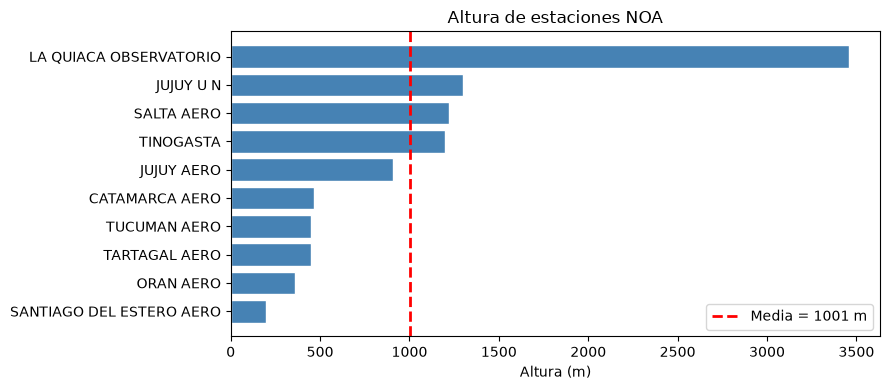

In [5]:
plt.figure(figsize=(9, 4))
alt_sorted = alt_por_estacion.sort_values('altura')
plt.barh(alt_sorted['estacion'], alt_sorted['altura'], color='steelblue', edgecolor='white')
plt.axvline(alt_por_estacion['altura'].mean(), color='red', lw=2, linestyle='--',
            label=f'Media = {alt_por_estacion["altura"].mean():.0f} m')
plt.title('Altura de estaciones NOA')
plt.xlabel('Altura (m)')
plt.legend()
plt.tight_layout()
plt.show()


---
### Pregunta 3 — ¿Cuál es la temperatura media de la región?

**Respuesta: entre 15.1 °C y 20 °C**


In [6]:
temp_media = noa['temp'].mean()
temp_std   = noa['temp'].std()
print(f'Temperatura media: {temp_media:.2f} °C')
print(f'Desvío estándar:   {temp_std:.2f} °C')


Temperatura media: 18.67 °C
Desvío estándar:   5.57 °C


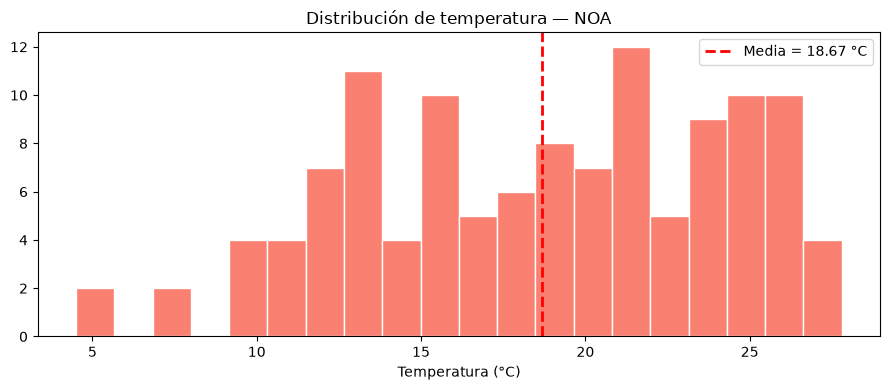

In [7]:
plt.figure(figsize=(9, 4))
plt.hist(noa['temp'].dropna(), bins=20, color='salmon', edgecolor='white')
plt.axvline(temp_media, color='red', lw=2, linestyle='--', label=f'Media = {temp_media:.2f} °C')
plt.title('Distribución de temperatura — NOA')
plt.xlabel('Temperatura (°C)')
plt.legend()
plt.tight_layout()
plt.show()


---
### Pregunta 4 — ¿Cuál es el desvío estándar de la temperatura?

**Respuesta: entre 5 °C y 10 °C**


In [8]:
print(noa['temp'].describe().round(2))


count    120.00
mean      18.67
std        5.57
min        4.50
25%       13.85
50%       19.20
75%       23.72
max       27.80
Name: temp, dtype: float64


---
### Pregunta 5 — ¿En qué mes se registra la mayor precipitación media?

**Respuesta: Enero**


mes_txt
Ene    142.66
Feb    125.47
Mar    103.26
Abr     39.85
May     14.01
Jun      6.02
Jul      2.89
Ago      2.99
Sep      8.54
Oct     35.28
Nov     64.13
Dic    110.32
Name: prec_mm, dtype: float64


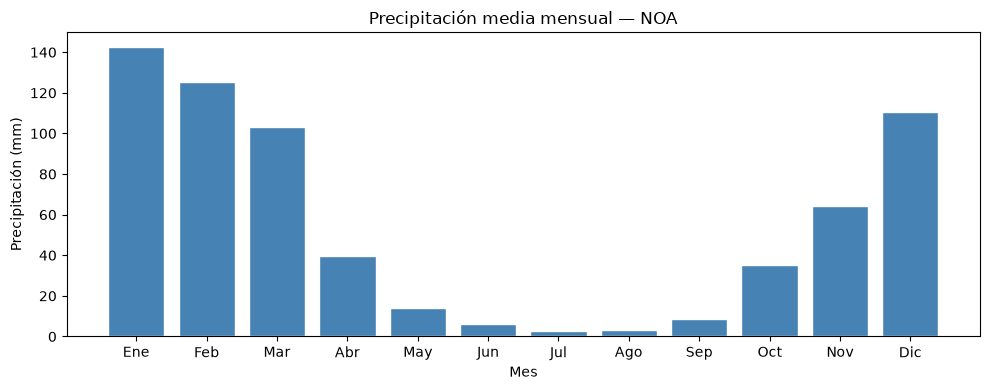

In [9]:
orden_mes = ['Ene','Feb','Mar','Abr','May','Jun','Jul','Ago','Sep','Oct','Nov','Dic']
prec_mes = noa.groupby('mes_txt')['prec_mm'].mean().reindex(orden_mes)
print(prec_mes.round(2))

plt.figure(figsize=(10, 4))
plt.bar(prec_mes.index, prec_mes.values, color='steelblue', edgecolor='white')
plt.title('Precipitación media mensual — NOA')
plt.xlabel('Mes')
plt.ylabel('Precipitación (mm)')
plt.tight_layout()
plt.show()


---
### Pregunta 6 — ¿Qué provincia tiene la mayor temperatura media?

**Respuesta: Santiago del Estero**


provincia
SANTIAGO DEL ES    20.58
CATAMARCA          20.12
SALTA              20.03
TUCUMAN            19.77
JUJUY              15.36
Name: temp, dtype: float64


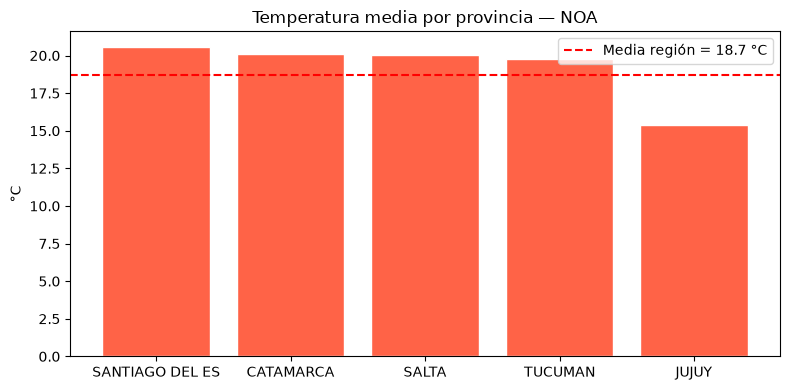

In [10]:
temp_prov = noa.groupby('provincia')['temp'].mean().sort_values(ascending=False).round(2)
print(temp_prov)

plt.figure(figsize=(8, 4))
plt.bar(temp_prov.index, temp_prov.values, color='tomato', edgecolor='white')
plt.axhline(noa['temp'].mean(), color='red', lw=1.5, linestyle='--', label=f'Media región = {noa["temp"].mean():.1f} °C')
plt.title('Temperatura media por provincia — NOA')
plt.ylabel('°C')
plt.legend()
plt.tight_layout()
plt.show()


---
### Pregunta 7 — ¿En cuál variable aparecen outliers?

**Respuesta: ninguna**


temp: Q1=13.8  Q3=23.7  IQR=9.9  límites=[-1.0, 38.5]  outliers=0
prec_mm: Q1=5.9  Q3=95.0  IQR=89.2  límites=[-128.0, 228.9]  outliers=0


/tmp/ipykernel_14538/1860982986.py:11: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax.boxplot(data, vert=False, patch_artist=True,
/tmp/ipykernel_14538/1860982986.py:11: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax.boxplot(data, vert=False, patch_artist=True,


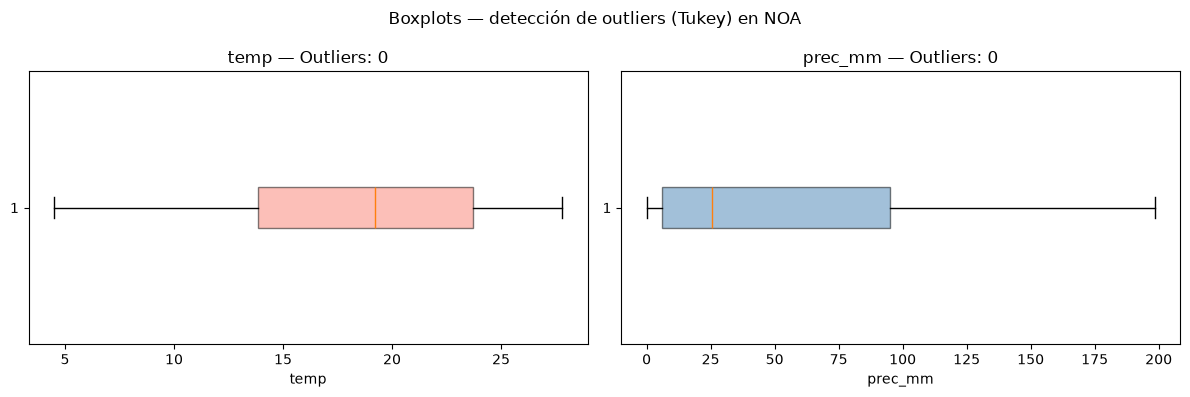

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, col, color in zip(axes, ['temp', 'prec_mm'], ['salmon', 'steelblue']):
    data = noa[col].dropna()
    q1, q3 = data.quantile(0.25), data.quantile(0.75)
    iqr = q3 - q1
    lim_lo = q1 - 1.5 * iqr
    lim_hi = q3 + 1.5 * iqr
    outliers = data[(data < lim_lo) | (data > lim_hi)]

    ax.boxplot(data, vert=False, patch_artist=True,
               boxprops=dict(facecolor=color, alpha=0.5))
    ax.set_title(f'{col} — Outliers: {len(outliers)}')
    ax.set_xlabel(col)
    print(f'{col}: Q1={q1:.1f}  Q3={q3:.1f}  IQR={iqr:.1f}  límites=[{lim_lo:.1f}, {lim_hi:.1f}]  outliers={len(outliers)}')

plt.suptitle('Boxplots — detección de outliers (Tukey) en NOA', fontsize=12)
plt.tight_layout()
plt.show()


---
### Pregunta 8 — Spearman entre altura y temperatura

**Respuesta: Existe una relación inversa — mayor altitud, menor temperatura**


Spearman r = -0.4602
p-valor    = 0.0000


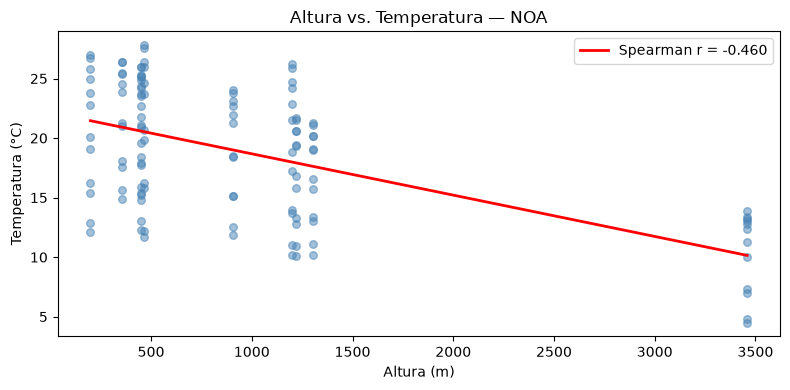

→ Correlación inversa moderada: a mayor altitud, menor temperatura.


In [12]:
sub = noa[['altura', 'temp']].dropna()
r, p = stats.spearmanr(sub['altura'], sub['temp'])
print(f'Spearman r = {r:.4f}')
print(f'p-valor    = {p:.4f}')

plt.figure(figsize=(8, 4))
plt.scatter(sub['altura'], sub['temp'], alpha=0.5, color='steelblue', s=30)
m, b = np.polyfit(sub['altura'], sub['temp'], 1)
x = np.linspace(sub['altura'].min(), sub['altura'].max(), 100)
plt.plot(x, m*x+b, color='red', lw=2, label=f'Spearman r = {r:.3f}')
plt.title('Altura vs. Temperatura — NOA')
plt.xlabel('Altura (m)')
plt.ylabel('Temperatura (°C)')
plt.legend()
plt.tight_layout()
plt.show()

print('→ Correlación inversa moderada: a mayor altitud, menor temperatura.')


---
### Pregunta 9 — Eta cuadrado: provincia vs. precipitación

**Respuesta: La asociación es débil o moderada; poca relación entre precipitación y provincia**


In [ ]:
grupos = [g['prec_mm'].dropna().values for _, g in noa.groupby('provincia')]
f, p_anova = stats.f_oneway(*grupos)

grand_mean = noa['prec_mm'].dropna().mean()
ss_total   = ((noa['prec_mm'].dropna() - grand_mean) ** 2).sum()
ss_between = sum(len(g) * (g.mean() - grand_mean) ** 2 for g in grupos)
eta2 = ss_between / ss_total

print(f'F        = {f:.2f}')
print(f'p-valor  = {p_anova:.4f}')
print(f'Eta²     = {eta2:.4f}')
print()
print('Interpretación de η²:  < 0.06 → débil  |  0.06–0.14 → moderado  |  > 0.14 → fuerte')
print(f'→ η² = {eta2:.2f}: asociación {"débil/moderada" if eta2 < 0.14 else "fuerte"} entre provincia y precipitación.')

plt.figure(figsize=(10, 4))
sns.boxplot(data=noa, x='provincia', y='prec_mm', palette='pastel', hue='provincia', legend=False)
plt.title(f'Precipitación por provincia — NOA  (η² = {eta2:.3f})')
plt.xlabel('Provincia')
plt.ylabel('Precipitación (mm)')
plt.tight_layout()
plt.show()


---
### Resumen NOA

| # | Respuesta correcta |
|---|-------------------|
| 1 | **≤ 10** estaciones (son exactamente 10) |
| 2 | **> 1000 m** (media ≈ 1001 m) |
| 3 | **entre 15.1 °C y 20 °C** (media ≈ 18.7 °C) |
| 4 | **entre 5 °C y 10 °C** (std ≈ 5.57 °C) |
| 5 | **Enero** (142.7 mm promedio) |
| 6 | **Santiago del Estero** (≈ 20.6 °C) |
| 7 | **Ninguna** (no hay outliers por criterio Tukey) |
| 8 | **Relación inversa** — mayor altitud, menor temperatura (r ≈ −0.46) |
| 9 | **Asociación débil/moderada** (η² ≈ 0.09) |


In [15]:
sde = df[df['provincia'] == 'SANTIAGO DEL ES']

print("=== SANTIAGO DEL ESTERO ===")
print(f"Temp media:      {sde['temp'].mean():.1f} °C")
print(f"Humedad media:   {sde['humedad'].mean():.1f} %")
print(f"Viento medio:    {sde['viento'].mean():.1f} km/h")
print()

orden = ['Ene','Feb','Mar','Abr','May','Jun','Jul','Ago','Sep','Oct','Nov','Dic']

print("Precipitación media por mes:")
print(sde.groupby('mes_txt')['prec_mm'].mean().reindex(orden).round(1))

=== SANTIAGO DEL ESTERO ===
Temp media:      20.6 °C
Humedad media:   64.0 %
Viento medio:    8.7 km/h

Precipitación media por mes:
mes_txt
Ene    139.3
Feb    106.5
Mar     94.3
Abr     39.9
May     16.0
Jun      9.3
Jul      1.6
Ago      3.5
Sep     10.0
Oct     55.2
Nov     71.8
Dic    105.0
Name: prec_mm, dtype: float64
